--- Data Pipeline Cleaned Successfully at 2026-09-10 19:33 ---
          Product_Name  Average_Market_Price  Your_Suggested_Retail_Price  \
0  Wireless Headphones                92.495                      83.2455   
1  Mechanical Keyboard               117.500                     105.7500   
2         Gaming Mouse                47.745                      42.9705   
3           4K Monitor               304.995                     274.4955   
4            USB-C Hub                23.750                      21.3750   
5         Webcam 1080p                72.490                      65.2410   

   Projected_Profit_Margin_USD  
0                      43.2455  
1                      55.7500  
2                      24.9705  
3                     124.4955  
4                      13.3750  
5                      35.2410  


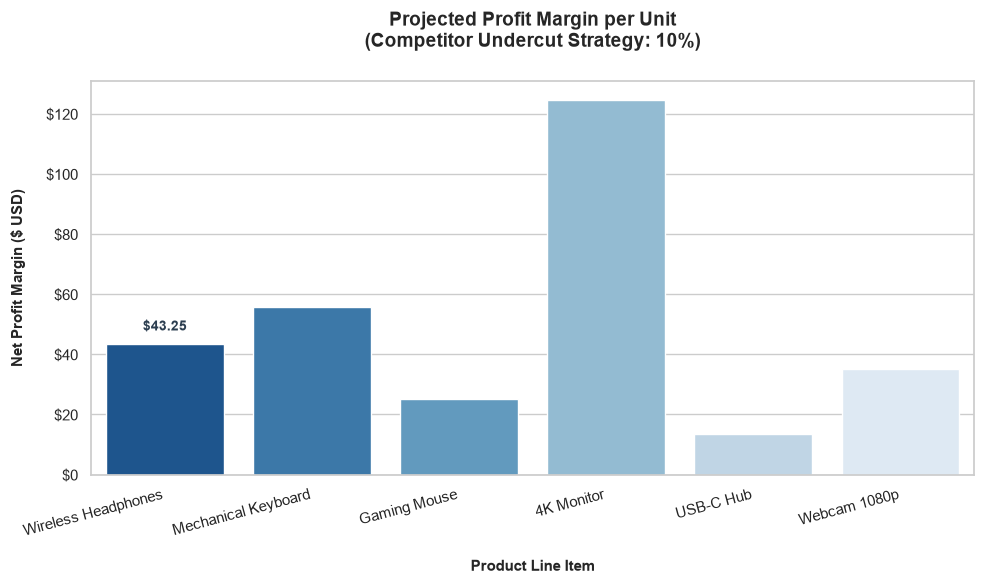

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime

# 1. Create simulated real-world competitor product data
data = {
    'Product_Name': ['Wireless Headphones', 'Mechanical Keyboard', 'Gaming Mouse', '4K Monitor', 'USB-C Hub', 'Webcam 1080p'],
    'Competitor_Price_A': [89.99, 120.00, 45.50, 299.99, 25.00, 69.99],
    'Competitor_Price_B': [95.00, 115.00, 49.99, 310.00, 22.50, 74.99],
    'Your_Target_Cost': [40.00, 50.00, 18.00, 150.00, 8.00, 30.00]
}

# 2. Convert data into a clean Pandas DataFrame
df = pd.DataFrame(data)

# 3. Data Processing: Calculate average market price and target markup strategy
df['Average_Market_Price'] = (df['Competitor_Price_A'] + df['Competitor_Price_B']) / 2
df['Your_Suggested_Retail_Price'] = df['Average_Market_Price'] * 0.90  # Underprice market by 10%
df['Projected_Profit_Margin_USD'] = df['Your_Suggested_Retail_Price'] - df['Your_Target_Cost']

# Display the polished data structure
print(f"--- Data Pipeline Cleaned Successfully at {datetime.now().strftime('%Y-%m-%d %H:%M')} ---")
print(df[['Product_Name', 'Average_Market_Price', 'Your_Suggested_Retail_Price', 'Projected_Profit_Margin_USD']])

# 4. Generate visual business analytics chart
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

# Generate the bar plot with a clean color palette
# Generate the bar plot with a clean color palette
barplot = sns.barplot(
    x='Product_Name', 
    y='Projected_Profit_Margin_USD', 
    data=df, 
    palette='Blues_r', 
    hue='Product_Name',  # Fixes the palette warning
    legend=False,        # Cleans up the workspace layout
    ax=ax
)

# Add exact price values perfectly centered on top of every single bar
ax.bar_label(
    ax.containers[0],    # Fixes the container formatting error
    fmt='$%.2f', 
    padding=8, 
    weight='bold', 
    size=10, 
    color='#2c3e50'
)
 

# Polish titles and axis labels
plt.title('Projected Profit Margin per Unit\n(Competitor Undercut Strategy: 10%)', pad=25, weight='bold', size=14)
plt.xlabel('Product Line Item', labelpad=15, weight='bold', size=11)
plt.ylabel('Net Profit Margin ($ USD)', labelpad=15, weight='bold', size=11)

# Format y-axis ticks directly as currency
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('$%1.0f'))

# Rotate labels slightly to avoid text overlap
plt.xticks(rotation=15, ha='right')

# Adjust layout to avoid clipped text outputs
plt.tight_layout()
plt.savefig('competitor_margin_analysis.png', dpi=300, bbox_inches='tight')
plt.show()